# Final Strategy Assessment

This notebook consolidates the evidence developed in Notebooks 02–08 and makes the final implementation decision for the Alpha Research Lab.

It is a synthesis and decision notebook, not a new strategy-search exercise. The factor set, candidate portfolios, rebalance configurations and transaction-cost assumption are frozen before the analysis begins.

The principal candidates are:

1. **Composite Score**, rebalanced every 21 trading days, as the provisional primary specification;
2. **Fixed 50/50 Sleeves**, rebalanced every 10 trading days, as the transparent allocation benchmark; and
3. **Pure Inverse Volatility**, rebalanced every 10 trading days, as the risk-based allocation benchmark.

All use offset zero and transaction costs of 10 basis points per unit of turnover.

The assessment covers:

1. input integrity and evidence reconciliation;
2. whole-sample performance and risk;
3. transaction-cost, phase and subperiod robustness;
4. turnover, liquidity and capacity;
5. beta, sector and contribution concentration;
6. complexity, transparency and interpretability;
7. the final implementation hierarchy;
8. risk-control and limitation decisions;
9. an evidence-backed claims register; and
10. reusable final exports for documentation and the Streamlit dashboard.

Notebook 09 does not treat the inspected sample as a pristine holdout. Its purpose is to organise the accumulated research evidence, state its limitations and make a disciplined implementation choice without introducing another layer of optimisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from alpha_research.config.paths import (
    PROCESSED_DATA_DIR,
)
from alpha_research.data_loader import (
    load_parquet,
)

pd.set_option(
    "display.max_columns",
    100,
)
pd.set_option(
    "display.width",
    180,
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)


TRADING_DAYS_PER_YEAR = 252
BASELINE_TRANSACTION_COST_BPS = 10.0
CAPACITY_PARTICIPATION_LIMIT = 0.01
ASSESSMENT_TOLERANCE = 1e-12


EXPECTED_IMPLEMENTATIONS = pd.DataFrame(
    [
        {
            "portfolio": "Composite Score",
            "rebalance_frequency": 21,
            "rebalance_offset": 0,
            "role": "Primary specification",
        },
        {
            "portfolio": "Fixed 50/50 Sleeves",
            "rebalance_frequency": 10,
            "rebalance_offset": 0,
            "role": ("Transparent sleeve benchmark"),
        },
        {
            "portfolio": ("Pure Inverse Volatility"),
            "rebalance_frequency": 10,
            "rebalance_offset": 0,
            "role": ("Risk-based sleeve benchmark"),
        },
    ]
)


CANDIDATE_ORDER = EXPECTED_IMPLEMENTATIONS["portfolio"].tolist()

SUBPERIOD_ORDER = [
    "2016–2018",
    "2019–2022",
    "2023–present",
]

## Decision framework

The final choice follows a hierarchy rather than an arbitrary weighted score.

### Eligibility gates

A candidate must have:

- reconciled accounting and aligned returns;
- acceptable data coverage;
- implementable turnover and liquidity;
- no unresolved structural breach; and
- a specification fixed before this notebook.

### Primary decision evidence

Eligible candidates are compared using:

- net performance and risk-adjusted return;
- drawdown behaviour;
- robustness across rebalance phases, costs and subperiods;
- turnover and conservative capacity;
- economic interpretability; and
- implementation simplicity.

### Contextual risk evidence

Current beta, volatility and concentration affect the interpretation and limitations of the selected strategy. They do not automatically re-optimise the candidate set because the monitoring state is already part of the inspected sample.

The assessment will therefore produce an evidence matrix and an explicit research judgement. It will not manufacture a single mechanically optimised ranking.

## 1. Evidence inputs and audit

Notebook 09 consumes versioned outputs from the optimisation, robustness, attribution and monitoring notebooks.

The audit verifies:

- required files and schemas;
- unique dataset keys;
- the frozen candidate specifications;
- common portfolio evaluation dates;
- availability of the 10-basis-point robustness results;
- phase, subperiod and rolling evidence;
- conservative 1% participation capacity estimates; and
- the latest monitoring state.

The purpose is to establish that the final decision is based on consistent prior evidence rather than notebook-local objects or manually copied results.

In [2]:
ASSESSMENT_FILENAMES = {
    "selected_implementations": ("attribution_selected_implementations.parquet"),
    "portfolio_daily": ("attribution_portfolio_daily.parquet"),
    "benchmark_daily": ("attribution_benchmark_daily.parquet"),
    "optimisation_summary": ("portfolio_optimisation_summary.parquet"),
    "mvo_forecast_diagnostics": ("mvo_forecast_diagnostics.parquet"),
    "mvo_shrinkage_sensitivity": ("mvo_shrinkage_sensitivity.parquet"),
    "robustness_offset_cost": ("portfolio_robustness_offset_cost_summary.parquet"),
    "robustness_subperiod": ("portfolio_robustness_subperiod_summary.parquet"),
    "robustness_rolling": ("portfolio_robustness_rolling_summary.parquet"),
    "robustness_turnover": ("portfolio_robustness_turnover_summary.parquet"),
    "robustness_capacity": ("portfolio_robustness_capacity_summary.parquet"),
    "monitoring_signal_health": ("strategy_monitoring_signal_health_daily.parquet"),
    "monitoring_performance_risk": (
        "strategy_monitoring_performance_risk_daily.parquet"
    ),
    "monitoring_beta": ("strategy_monitoring_beta_daily.parquet"),
    "monitoring_concentration": ("strategy_monitoring_concentration_daily.parquet"),
    "monitoring_implementation": ("strategy_monitoring_implementation_daily.parquet"),
    "monitoring_diagnostic_flags": ("strategy_monitoring_diagnostic_flags.parquet"),
    "monitoring_latest_overview": ("strategy_monitoring_latest_overview.parquet"),
}


missing_input_files = [
    filename
    for filename in ASSESSMENT_FILENAMES.values()
    if not (PROCESSED_DATA_DIR / filename).exists()
]

if missing_input_files:
    raise FileNotFoundError(
        "Notebook 09 is missing required " "evidence files: " f"{missing_input_files}"
    )


assessment_datasets = {
    dataset_name: load_parquet(PROCESSED_DATA_DIR / filename)
    for dataset_name, filename in ASSESSMENT_FILENAMES.items()
}


DATE_COLUMNS = {
    "date",
    "start_date",
    "end_date",
    "latest_date",
}

for dataframe in assessment_datasets.values():
    for column in DATE_COLUMNS & set(dataframe.columns):
        dataframe[column] = pd.to_datetime(dataframe[column])


selected_implementations = assessment_datasets["selected_implementations"]

portfolio_daily = assessment_datasets["portfolio_daily"]

benchmark_daily = assessment_datasets["benchmark_daily"]

optimisation_summary = assessment_datasets["optimisation_summary"]

mvo_forecast_diagnostics = assessment_datasets["mvo_forecast_diagnostics"]

mvo_shrinkage_sensitivity = assessment_datasets["mvo_shrinkage_sensitivity"]

robustness_offset_cost = assessment_datasets["robustness_offset_cost"]

robustness_subperiod = assessment_datasets["robustness_subperiod"]

robustness_rolling = assessment_datasets["robustness_rolling"]

robustness_turnover = assessment_datasets["robustness_turnover"]

robustness_capacity = assessment_datasets["robustness_capacity"]

monitoring_signal_health = assessment_datasets["monitoring_signal_health"]

monitoring_performance_risk = assessment_datasets["monitoring_performance_risk"]

monitoring_beta = assessment_datasets["monitoring_beta"]

monitoring_concentration = assessment_datasets["monitoring_concentration"]

monitoring_implementation = assessment_datasets["monitoring_implementation"]

monitoring_diagnostic_flags = assessment_datasets["monitoring_diagnostic_flags"]

monitoring_latest_overview = assessment_datasets["monitoring_latest_overview"]

In [3]:
ASSESSMENT_DATASET_KEYS = {
    "selected_implementations": [
        "portfolio",
    ],
    "portfolio_daily": [
        "portfolio",
        "date",
    ],
    "benchmark_daily": [
        "benchmark",
        "date",
    ],
    "optimisation_summary": [
        "portfolio",
    ],
    "mvo_forecast_diagnostics": [
        "metric",
    ],
    "mvo_shrinkage_sensitivity": [
        "mvo_intensity",
    ],
    "robustness_offset_cost": [
        "portfolio",
        "rebalance_frequency",
        "transaction_cost_bps",
    ],
    "robustness_subperiod": [
        "subperiod",
        "portfolio",
        "rebalance_frequency",
    ],
    "robustness_rolling": [
        "portfolio",
        "rebalance_frequency",
    ],
    "robustness_turnover": [
        "portfolio",
        "rebalance_frequency",
    ],
    "robustness_capacity": [
        "portfolio",
        "rebalance_frequency",
        "participation_limit",
    ],
    "monitoring_signal_health": [
        "factor",
        "date",
    ],
    "monitoring_performance_risk": [
        "portfolio",
        "date",
    ],
    "monitoring_beta": [
        "portfolio",
        "date",
    ],
    "monitoring_concentration": [
        "portfolio",
        "date",
    ],
    "monitoring_implementation": [
        "portfolio",
        "date",
    ],
    "monitoring_diagnostic_flags": [
        "entity_type",
        "entity",
        "category",
        "diagnostic",
    ],
    "monitoring_latest_overview": [
        "entity_type",
        "entity",
    ],
}


assessment_input_rows = []

for dataset_name, dataframe in assessment_datasets.items():
    key_columns = ASSESSMENT_DATASET_KEYS[dataset_name]

    missing_key_columns = set(key_columns) - set(dataframe.columns)

    if missing_key_columns:
        raise KeyError(
            f"{dataset_name} is missing "
            "key columns: "
            f"{sorted(missing_key_columns)}"
        )

    duplicate_key_rows = dataframe.duplicated(
        key_columns,
        keep=False,
    ).sum()

    date_column = next(
        (
            column
            for column in [
                "date",
                "latest_date",
            ]
            if column in dataframe.columns
        ),
        None,
    )

    assessment_input_rows.append(
        {
            "dataset": dataset_name,
            "rows": len(dataframe),
            "columns": (dataframe.shape[1]),
            "start_date": (
                dataframe[date_column].min() if date_column is not None else pd.NaT
            ),
            "end_date": (
                dataframe[date_column].max() if date_column is not None else pd.NaT
            ),
            "duplicate_key_rows": (duplicate_key_rows),
        }
    )


assessment_input_audit = pd.DataFrame(assessment_input_rows)

display(assessment_input_audit)


if assessment_input_audit["rows"].eq(0).any():
    raise ValueError("At least one evidence dataset " "is empty.")


if assessment_input_audit["duplicate_key_rows"].gt(0).any():
    raise ValueError("Duplicate evidence keys found.")

,dataset,rows,columns,start_date,end_date,duplicate_key_rows
0,selected_implementations,3,4,NaT,NaT,0
1,portfolio_daily,7905,20,2016-01-07,2026-07-01,0
2,benchmark_daily,2635,3,2016-01-07,2026-07-01,0
3,optimisation_summary,8,15,NaT,NaT,0
4,mvo_forecast_diagnostics,12,2,NaT,NaT,0
5,mvo_shrinkage_sensitivity,5,13,NaT,NaT,0
6,robustness_offset_cost,60,14,NaT,NaT,0
7,robustness_subperiod,36,14,NaT,NaT,0
8,robustness_rolling,12,10,NaT,NaT,0
9,robustness_turnover,12,13,NaT,NaT,0


In [4]:
SPECIFICATION_COLUMNS = [
    "portfolio",
    "rebalance_frequency",
    "rebalance_offset",
    "role",
]


expected_specifications = (
    EXPECTED_IMPLEMENTATIONS[SPECIFICATION_COLUMNS]
    .sort_values("portfolio")
    .reset_index(drop=True)
)

actual_specifications = (
    selected_implementations[SPECIFICATION_COLUMNS]
    .sort_values("portfolio")
    .reset_index(drop=True)
)


implementation_specification_audit = expected_specifications.merge(
    actual_specifications,
    on=SPECIFICATION_COLUMNS,
    how="outer",
    indicator="match_status",
)

display(implementation_specification_audit)


if not (implementation_specification_audit["match_status"].eq("both").all()):
    raise ValueError(
        "The selected implementations do "
        "not match the frozen Notebook 09 "
        "candidate specifications."
    )


selected_frequency_lookup = EXPECTED_IMPLEMENTATIONS.set_index("portfolio")[
    "rebalance_frequency"
].to_dict()


def selected_configuration_mask(
    dataframe,
):
    expected_frequency = dataframe["portfolio"].map(selected_frequency_lookup)

    return dataframe["portfolio"].isin(CANDIDATE_ORDER) & dataframe[
        "rebalance_frequency"
    ].eq(expected_frequency)


baseline_offset_cost_evidence = robustness_offset_cost.loc[
    selected_configuration_mask(robustness_offset_cost)
    & robustness_offset_cost["transaction_cost_bps"].eq(BASELINE_TRANSACTION_COST_BPS)
]


selected_subperiod_evidence = robustness_subperiod.loc[
    selected_configuration_mask(robustness_subperiod)
]


selected_rolling_evidence = robustness_rolling.loc[
    selected_configuration_mask(robustness_rolling)
]


selected_capacity_evidence = robustness_capacity.loc[
    selected_configuration_mask(robustness_capacity)
    & np.isclose(
        robustness_capacity["participation_limit"],
        CAPACITY_PARTICIPATION_LIMIT,
    )
]


portfolio_date_audit = (
    portfolio_daily.groupby("portfolio")
    .agg(
        observations=(
            "date",
            "size",
        ),
        start_date=(
            "date",
            "min",
        ),
        end_date=(
            "date",
            "max",
        ),
    )
    .reindex(CANDIDATE_ORDER)
)


evidence_coverage_audit = pd.DataFrame(
    [
        {
            "evidence": ("Baseline phase and cost"),
            "expected_rows": 3,
            "observed_rows": len(baseline_offset_cost_evidence),
        },
        {
            "evidence": ("Subperiod robustness"),
            "expected_rows": (len(CANDIDATE_ORDER) * len(SUBPERIOD_ORDER)),
            "observed_rows": len(selected_subperiod_evidence),
        },
        {
            "evidence": ("Rolling stability"),
            "expected_rows": 3,
            "observed_rows": len(selected_rolling_evidence),
        },
        {
            "evidence": ("Capacity at 1% participation"),
            "expected_rows": 3,
            "observed_rows": len(selected_capacity_evidence),
        },
        {
            "evidence": ("Latest portfolio monitoring"),
            "expected_rows": 3,
            "observed_rows": len(
                monitoring_latest_overview.loc[
                    monitoring_latest_overview["entity_type"].eq("Portfolio")
                ]
            ),
        },
    ]
)


evidence_coverage_audit["audit_passes"] = evidence_coverage_audit["observed_rows"].eq(
    evidence_coverage_audit["expected_rows"]
)


display(portfolio_date_audit)

display(evidence_coverage_audit)


if portfolio_date_audit.isna().any().any():
    raise ValueError(
        "At least one frozen candidate is " "missing from portfolio_daily."
    )


if (
    portfolio_date_audit[
        [
            "observations",
            "start_date",
            "end_date",
        ]
    ]
    .nunique()
    .gt(1)
    .any()
):
    raise ValueError("Candidate portfolio samples do " "not align.")


if not evidence_coverage_audit["audit_passes"].all():
    raise ValueError("Required decision evidence is " "incomplete.")


if "Maximum-Sharpe MVO" in set(selected_implementations["portfolio"]):
    raise ValueError("Rejected MVO unexpectedly appears " "in the candidate set.")

,portfolio,rebalance_frequency,rebalance_offset,role,match_status
0,Composite Score,21,0,Primary specification,both
1,Fixed 50/50 Sleeves,10,0,Transparent sleeve benchmark,both
2,Pure Inverse Volatility,10,0,Risk-based sleeve benchmark,both


,observations,start_date,end_date
portfolio,,,
Composite Score,2635,2016-01-07,2026-07-01
Fixed 50/50 Sleeves,2635,2016-01-07,2026-07-01
Pure Inverse Volatility,2635,2016-01-07,2026-07-01


,evidence,expected_rows,observed_rows,audit_passes
0,Baseline phase and cost,3,3,True
1,Subperiod robustness,9,9,True
2,Rolling stability,3,3,True
3,Capacity at 1% participation,3,3,True
4,Latest portfolio monitoring,3,3,True


### 1.1 Evidence-audit findings

#### 1. Input integrity

- All 18 required evidence datasets are present and non-empty.
- No duplicate dataset keys are detected.
- All five Notebook 06 robustness exports pass their read-back checks.

#### 2. Frozen specifications

The three implementations match the predefined candidate set exactly:

1. Composite Score — 21-day rebalancing;
2. Fixed 50/50 Sleeves — 10-day rebalancing; and
3. Pure Inverse Volatility — 10-day rebalancing.

All use offset zero and retain their previously assigned research roles.

#### 3. Sample alignment

Each candidate contains 2,635 daily observations from 7 January 2016 to 1 July 2026. Their evaluation samples therefore align exactly.

#### 4. Evidence coverage

The assessment has complete coverage of:

- baseline transaction-cost and rebalance-phase results;
- three predefined subperiods;
- rolling stability;
- capacity at a 1% participation limit; and
- the latest portfolio-monitoring state.

The final assessment can proceed without notebook-local results, manually copied statistics or additional optimisation.

## 2. Whole-sample performance and phase robustness

This section establishes the headline economic comparison among the frozen candidates.

Two views are kept separate:

### 2.1 Frozen offset-zero results

These are the realised results of the exact implementations selected in Notebook 06 and attributed in Notebook 07.

### 2.2 Phase-averaged results

These average across every valid rebalance offset at the selected frequency. They measure whether the headline result is representative or depends on a favourable calendar phase.

SPY is included only as market context. It is not a directly comparable long-only alternative to the long/short portfolios, whose gross exposure, beta and concentration can differ substantially.

Returns are annualised geometrically. Volatility and Sharpe ratios use 252 trading days and a zero risk-free rate.

### 2.3 Return-summary helper

In [5]:
def summarise_return_series(
    return_series: pd.Series,
) -> pd.Series:
    returns = pd.Series(return_series).dropna().astype(float)

    if len(returns) < 2:
        raise ValueError("At least two valid returns are " "required.")

    if returns.le(-1.0).any():
        raise ValueError(
            "Return series contains a value " "less than or equal to -100%."
        )

    observations = len(returns)

    wealth_path = np.cumprod(1.0 + returns.to_numpy())

    ending_wealth = wealth_path[-1]

    annualised_return = ending_wealth ** (TRADING_DAYS_PER_YEAR / observations) - 1.0

    daily_volatility = returns.std(ddof=1)

    annualised_volatility = daily_volatility * np.sqrt(TRADING_DAYS_PER_YEAR)

    sharpe_ratio = (
        returns.mean() / daily_volatility * np.sqrt(TRADING_DAYS_PER_YEAR)
        if daily_volatility > 0
        else np.nan
    )

    running_peak = np.maximum.accumulate(
        np.r_[
            1.0,
            wealth_path,
        ]
    )[1:]

    drawdown = wealth_path / running_peak - 1.0

    return pd.Series(
        {
            "observations": observations,
            "total_return": (ending_wealth - 1.0),
            "annualised_return": (annualised_return),
            "annualised_volatility": (annualised_volatility),
            "sharpe_ratio": sharpe_ratio,
            "maximum_drawdown": (drawdown.min()),
            "positive_day_fraction": (returns.gt(0.0).mean()),
        }
    )

### 2.4 Frozen candidate performance

In [6]:
candidate_headline_rows = []


for _, specification in EXPECTED_IMPLEMENTATIONS.iterrows():
    portfolio_name = specification["portfolio"]

    portfolio_data = (
        portfolio_daily.loc[portfolio_daily["portfolio"].eq(portfolio_name)]
        .sort_values("date")
        .copy()
    )

    if portfolio_data.empty:
        raise ValueError(f"{portfolio_name} is missing " "from portfolio_daily.")

    actual_configurations = portfolio_data[
        [
            "rebalance_frequency",
            "rebalance_offset",
            "transaction_cost_bps",
        ]
    ].drop_duplicates()

    if len(actual_configurations) != 1:
        raise ValueError(f"{portfolio_name} contains " "multiple configurations.")

    actual_configuration = actual_configurations.iloc[0]

    expected_configuration = {
        "rebalance_frequency": (specification["rebalance_frequency"]),
        "rebalance_offset": (specification["rebalance_offset"]),
        "transaction_cost_bps": (BASELINE_TRANSACTION_COST_BPS),
    }

    for column, expected_value in expected_configuration.items():
        if not np.isclose(
            actual_configuration[column],
            expected_value,
        ):
            raise ValueError(f"{portfolio_name} has an " f"unexpected {column}.")

    gross_summary = summarise_return_series(portfolio_data["gross_return"])

    net_summary = summarise_return_series(portfolio_data["net_return"])

    rebalance_turnover = portfolio_data.loc[
        portfolio_data["is_rebalance"].astype(bool),
        "turnover",
    ]

    candidate_headline_rows.append(
        {
            "portfolio": portfolio_name,
            "role": specification["role"],
            "rebalance_frequency": (specification["rebalance_frequency"]),
            "rebalance_offset": (specification["rebalance_offset"]),
            "observations": int(net_summary["observations"]),
            "gross_annualised_return": (gross_summary["annualised_return"]),
            "net_annualised_return": (net_summary["annualised_return"]),
            "annualised_return_cost_drag": (
                gross_summary["annualised_return"] - net_summary["annualised_return"]
            ),
            "net_annualised_volatility": (net_summary["annualised_volatility"]),
            "net_sharpe": (net_summary["sharpe_ratio"]),
            "net_maximum_drawdown": (net_summary["maximum_drawdown"]),
            "net_positive_day_fraction": (net_summary["positive_day_fraction"]),
            "average_daily_turnover": (portfolio_data["turnover"].mean()),
            "average_rebalance_turnover": (rebalance_turnover.mean()),
            "total_transaction_cost": (portfolio_data["transaction_cost"].sum()),
        }
    )


candidate_headline_performance = (
    pd.DataFrame(candidate_headline_rows)
    .set_index("portfolio")
    .reindex(CANDIDATE_ORDER)
    .reset_index()
)

### 2.5 SPY context and whole-sample comparison

In [7]:
if benchmark_daily["benchmark"].nunique() != 1:
    raise ValueError("Expected exactly one benchmark.")


benchmark_name = benchmark_daily["benchmark"].iloc[0]


candidate_dates = (
    portfolio_daily.loc[
        portfolio_daily["portfolio"].eq(CANDIDATE_ORDER[0]),
        "date",
    ]
    .sort_values()
    .reset_index(drop=True)
)


benchmark_dates = benchmark_daily["date"].sort_values().reset_index(drop=True)


if not candidate_dates.equals(benchmark_dates):
    raise ValueError("The benchmark and candidate " "evaluation dates do not align.")


benchmark_summary = summarise_return_series(benchmark_daily["benchmark_return"])


benchmark_headline_performance = pd.DataFrame(
    [
        {
            "portfolio": (benchmark_name),
            "role": ("Long-only market context"),
            "observations": int(benchmark_summary["observations"]),
            "annualised_return": (benchmark_summary["annualised_return"]),
            "annualised_volatility": (benchmark_summary["annualised_volatility"]),
            "sharpe_ratio": (benchmark_summary["sharpe_ratio"]),
            "maximum_drawdown": (benchmark_summary["maximum_drawdown"]),
            "positive_day_fraction": (benchmark_summary["positive_day_fraction"]),
        }
    ]
)


whole_sample_performance_comparison = (
    pd.concat(
        [
            candidate_headline_performance[
                [
                    "portfolio",
                    "role",
                    "observations",
                    "net_annualised_return",
                    "net_annualised_volatility",
                    "net_sharpe",
                    "net_maximum_drawdown",
                    "net_positive_day_fraction",
                ]
            ].rename(
                columns={
                    "net_annualised_return": ("annualised_return"),
                    "net_annualised_volatility": ("annualised_volatility"),
                    "net_sharpe": ("sharpe_ratio"),
                    "net_maximum_drawdown": ("maximum_drawdown"),
                    "net_positive_day_fraction": ("positive_day_fraction"),
                }
            ),
            benchmark_headline_performance,
        ],
        ignore_index=True,
    )
    .set_index("portfolio")
    .reindex(CANDIDATE_ORDER + [benchmark_name])
)


display(whole_sample_performance_comparison.round(4))

,role,observations,annualised_return,annualised_volatility,sharpe_ratio,maximum_drawdown,positive_day_fraction
portfolio,,,,,,,
Composite Score,Primary specification,2635,0.1613,0.2117,0.8128,-0.2924,0.5529
Fixed 50/50 Sleeves,Transparent sleeve benchmark,2635,0.1084,0.1677,0.6983,-0.2568,0.5438
Pure Inverse Volatility,Risk-based sleeve benchmark,2635,0.1096,0.1625,0.7215,-0.2177,0.5476
SPY,Long-only market context,2635,0.1555,0.1783,0.9004,-0.3372,0.5545


### 2.6 Phase-robustness evidence

In [8]:
PHASE_ROBUSTNESS_COLUMNS = [
    "portfolio",
    "rebalance_frequency",
    "transaction_cost_bps",
    "offset_count",
    "mean_net_annualised_return",
    "median_net_annualised_return",
    "minimum_net_annualised_return",
    "maximum_net_annualised_return",
    "mean_net_sharpe",
    "median_net_sharpe",
    "minimum_net_sharpe",
    "maximum_net_sharpe",
    "worst_max_drawdown",
    "mean_daily_turnover",
]


phase_robustness_evidence = baseline_offset_cost_evidence[
    PHASE_ROBUSTNESS_COLUMNS
].copy()


expected_offset_count = phase_robustness_evidence["portfolio"].map(
    selected_frequency_lookup
)


if not phase_robustness_evidence["offset_count"].eq(expected_offset_count).all():
    raise ValueError(
        "The phase-robustness table does " "not contain every valid offset."
    )


phase_robustness_evidence["return_offset_range"] = (
    phase_robustness_evidence["maximum_net_annualised_return"]
    - phase_robustness_evidence["minimum_net_annualised_return"]
)


phase_robustness_evidence["sharpe_offset_range"] = (
    phase_robustness_evidence["maximum_net_sharpe"]
    - phase_robustness_evidence["minimum_net_sharpe"]
)


phase_robustness_evidence = (
    phase_robustness_evidence.set_index("portfolio")
    .reindex(CANDIDATE_ORDER)
    .reset_index()
)


display(phase_robustness_evidence.round(4))

,portfolio,rebalance_frequency,transaction_cost_bps,offset_count,mean_net_annualised_return,median_net_annualised_return,minimum_net_annualised_return,maximum_net_annualised_return,mean_net_sharpe,median_net_sharpe,minimum_net_sharpe,maximum_net_sharpe,worst_max_drawdown,mean_daily_turnover,return_offset_range,sharpe_offset_range
0,Composite Score,21,10.0,21,0.1584,0.1577,0.1346,0.1773,0.8022,0.8010,0.7013,0.8818,-0.3924,0.0511,0.0426,0.1804
1,Fixed 50/50 Sleeves,10,10.0,10,0.1050,0.1047,0.0944,0.1131,0.6798,0.6798,0.6238,0.7249,-0.2752,0.0617,0.0187,0.1011
2,Pure Inverse Volatility,10,10.0,10,0.1110,0.1113,0.0983,0.1191,0.7292,0.7319,0.6608,0.7683,-0.2353,0.0655,0.0208,0.1075


### 2.7 Consolidated candidate scorecard

In [10]:
spy_annualised_return = benchmark_summary["annualised_return"]

spy_sharpe = benchmark_summary["sharpe_ratio"]


candidate_scorecard = candidate_headline_performance.merge(
    phase_robustness_evidence[
        [
            "portfolio",
            "offset_count",
            "mean_net_annualised_return",
            "minimum_net_annualised_return",
            "maximum_net_annualised_return",
            "mean_net_sharpe",
            "minimum_net_sharpe",
            "maximum_net_sharpe",
            "worst_max_drawdown",
            "mean_daily_turnover",
            "return_offset_range",
            "sharpe_offset_range",
        ]
    ],
    on="portfolio",
    how="left",
    validate="one_to_one",
    suffixes=(
        "_offset_zero",
        "_phase_average",
    ),
)

candidate_scorecard = candidate_headline_performance.merge(
    phase_robustness_evidence[
        [
            "portfolio",
            "offset_count",
            "mean_net_annualised_return",
            "minimum_net_annualised_return",
            "maximum_net_annualised_return",
            "mean_net_sharpe",
            "minimum_net_sharpe",
            "maximum_net_sharpe",
            "worst_max_drawdown",
            "mean_daily_turnover",
            "return_offset_range",
            "sharpe_offset_range",
        ]
    ],
    on="portfolio",
    how="left",
    validate="one_to_one",
).rename(
    columns={
        "average_daily_turnover": ("average_daily_turnover_offset_zero"),
        "mean_daily_turnover": ("mean_daily_turnover_phase_average"),
    }
)

candidate_scorecard["offset_zero_minus_phase_mean_return"] = (
    candidate_scorecard["net_annualised_return"]
    - candidate_scorecard["mean_net_annualised_return"]
)


candidate_scorecard["offset_zero_minus_phase_mean_sharpe"] = (
    candidate_scorecard["net_sharpe"] - candidate_scorecard["mean_net_sharpe"]
)


candidate_scorecard["net_annualised_return_minus_spy"] = (
    candidate_scorecard["net_annualised_return"] - spy_annualised_return
)


candidate_scorecard["net_sharpe_minus_spy"] = (
    candidate_scorecard["net_sharpe"] - spy_sharpe
)


candidate_scorecard = (
    candidate_scorecard.set_index("portfolio").reindex(CANDIDATE_ORDER).reset_index()
)


SCORECARD_REQUIRED_COLUMNS = [
    "net_annualised_return",
    "net_annualised_volatility",
    "net_sharpe",
    "net_maximum_drawdown",
    "mean_net_annualised_return",
    "minimum_net_annualised_return",
    "mean_net_sharpe",
    "minimum_net_sharpe",
    "worst_max_drawdown",
    "return_offset_range",
    "sharpe_offset_range",
]


if len(candidate_scorecard) != len(CANDIDATE_ORDER):
    raise ValueError(
        "The candidate scorecard does not " "contain exactly three candidates."
    )


if candidate_scorecard[SCORECARD_REQUIRED_COLUMNS].isna().any().any():
    raise ValueError("The candidate scorecard contains " "missing decision metrics.")


if (
    candidate_scorecard["gross_annualised_return"] + ASSESSMENT_TOLERANCE
    < candidate_scorecard["net_annualised_return"]
).any():
    raise ValueError("Net annualised return exceeds " "gross annualised return.")


CANDIDATE_SCORECARD_DISPLAY_COLUMNS = [
    "portfolio",
    "rebalance_frequency",
    "net_annualised_return",
    "net_annualised_volatility",
    "net_sharpe",
    "net_maximum_drawdown",
    "annualised_return_cost_drag",
    "mean_net_annualised_return",
    "minimum_net_annualised_return",
    "mean_net_sharpe",
    "minimum_net_sharpe",
    "worst_max_drawdown",
    "offset_zero_minus_phase_mean_return",
    "offset_zero_minus_phase_mean_sharpe",
    "return_offset_range",
    "sharpe_offset_range",
    "average_daily_turnover_offset_zero",
    "mean_daily_turnover_phase_average",
    "net_annualised_return_minus_spy",
    "net_sharpe_minus_spy",
]


display(candidate_scorecard[CANDIDATE_SCORECARD_DISPLAY_COLUMNS].round(4))

,portfolio,rebalance_frequency,net_annualised_return,net_annualised_volatility,net_sharpe,net_maximum_drawdown,annualised_return_cost_drag,mean_net_annualised_return,minimum_net_annualised_return,mean_net_sharpe,minimum_net_sharpe,worst_max_drawdown,offset_zero_minus_phase_mean_return,offset_zero_minus_phase_mean_sharpe,return_offset_range,sharpe_offset_range,average_daily_turnover_offset_zero,mean_daily_turnover_phase_average,net_annualised_return_minus_spy,net_sharpe_minus_spy
0,Composite Score,21,0.1613,0.2117,0.8128,-0.2924,0.0150,0.1584,0.1346,0.8022,0.7013,-0.3924,0.0029,0.0105,0.0426,0.1804,0.0509,0.0511,0.0057,-0.0876
1,Fixed 50/50 Sleeves,10,0.1084,0.1677,0.6983,-0.2568,0.0175,0.1050,0.0944,0.6798,0.6238,-0.2752,0.0034,0.0185,0.0187,0.1011,0.0624,0.0617,-0.0471,-0.2021
2,Pure Inverse Volatility,10,0.1096,0.1625,0.7215,-0.2177,0.0186,0.1110,0.0983,0.7292,0.6608,-0.2353,-0.0014,-0.0077,0.0208,0.1075,0.0660,0.0655,-0.0459,-0.1789


### 2.8 Whole-sample findings

#### 1. Composite Score provides the strongest headline performance

- Net annualised return is 16.1%, compared with approximately 11.0% for both sleeve implementations.
- Its net Sharpe ratio is 0.81, versus 0.70 for Fixed 50/50 and 0.72 for Pure Inverse Volatility.
- Its offset-zero result is close to its phase average: the return difference is only 0.3 percentage points and the Sharpe difference is 0.01.
- Its performance lead therefore does not depend on the selected rebalance phase.

This advantage comes with higher risk. Composite Score has 21.2% annualised volatility and a 29.2% maximum drawdown.

#### 2. Pure Inverse Volatility provides the best defensive profile

- It has the lowest volatility, at 16.3%.
- It has the least severe maximum drawdown, at 21.8%.
- It slightly exceeds Fixed 50/50 in both return and Sharpe ratio.
- Its offset-zero results are marginally below its phase averages, indicating that its headline result is not supported by a favourable phase choice.

Pure Inverse Volatility is therefore the strongest risk-based benchmark. Fixed 50/50 remains useful primarily because of its transparency and simplicity.

#### 3. All candidates survive the rebalance-phase test

At the selected frequencies, every rebalance phase produces:

- a positive annualised return;
- a positive Sharpe ratio; and
- broadly similar average daily turnover.

Composite Score has the widest phase range, partly because its 21-day frequency creates 21 distinct phases. Nevertheless, its worst phase still produces a 13.5% annualised return and a 0.70 Sharpe ratio, exceeding the worst-phase results of both sleeve portfolios.

#### 4. SPY remains an important qualification

Composite Score exceeds SPY's annualised return by only 0.6 percentage points while carrying higher volatility. Its Sharpe ratio is 0.09 lower than SPY's, although its maximum drawdown is less severe.

SPY is not a like-for-like strategy benchmark, but this comparison prevents the portfolio's strong return from being presented as unqualified market-adjusted outperformance. Later sections must distinguish diversified alpha from the elevated beta and concentration documented in Notebook 08.

#### 5. Provisional assessment

Composite Score remains the leading primary candidate because it combines the highest return, the highest candidate Sharpe ratio, the lowest turnover and strong phase robustness.

Pure Inverse Volatility remains the strongest alternative where drawdown control and lower volatility are prioritised. The hierarchy remains provisional until cost sensitivity, subperiod consistency and rolling stability have been assessed.

## 3. Cost, subperiod, and rolling robustness

Whole-sample results can conceal three important weaknesses:

1. returns may disappear under less favourable transaction costs;
2. performance may be concentrated in one market regime; or
3. the full-sample Sharpe ratio may not represent shorter rolling periods.

This section therefore evaluates:

- phase-averaged performance across the transaction-cost grid;
- phase-averaged results in the three predefined subperiods; and
- the distribution of rolling phase-averaged Sharpe ratios.

The selected portfolio definitions and rebalance frequencies remain fixed throughout.

### 3.1 Cost sensitivity

In [11]:
selected_cost_sensitivity = robustness_offset_cost.loc[
    selected_configuration_mask(robustness_offset_cost)
].copy()


transaction_cost_grid = sorted(
    selected_cost_sensitivity["transaction_cost_bps"].unique()
)


expected_cost_rows = len(CANDIDATE_ORDER) * len(transaction_cost_grid)


if len(selected_cost_sensitivity) != expected_cost_rows:
    raise ValueError("Incomplete selected-configuration " "cost-sensitivity evidence.")


expected_offset_count = selected_cost_sensitivity["portfolio"].map(
    selected_frequency_lookup
)


if not selected_cost_sensitivity["offset_count"].eq(expected_offset_count).all():
    raise ValueError(
        "At least one cost scenario does not " "contain every rebalance offset."
    )


portfolio_order_lookup = {
    portfolio: order for order, portfolio in enumerate(CANDIDATE_ORDER)
}


selected_cost_sensitivity["portfolio_order"] = selected_cost_sensitivity[
    "portfolio"
].map(portfolio_order_lookup)


selected_cost_sensitivity = (
    selected_cost_sensitivity.sort_values(
        [
            "portfolio_order",
            "transaction_cost_bps",
        ]
    )
    .drop(columns="portfolio_order")
    .reset_index(drop=True)
)


cost_return_table = (
    selected_cost_sensitivity.pivot(
        index="portfolio",
        columns="transaction_cost_bps",
        values="mean_net_annualised_return",
    )
    .reindex(CANDIDATE_ORDER)
    .reindex(columns=transaction_cost_grid)
)


cost_sharpe_table = (
    selected_cost_sensitivity.pivot(
        index="portfolio",
        columns="transaction_cost_bps",
        values="mean_net_sharpe",
    )
    .reindex(CANDIDATE_ORDER)
    .reindex(columns=transaction_cost_grid)
)


worst_phase_cost_sharpe_table = (
    selected_cost_sensitivity.pivot(
        index="portfolio",
        columns="transaction_cost_bps",
        values="minimum_net_sharpe",
    )
    .reindex(CANDIDATE_ORDER)
    .reindex(columns=transaction_cost_grid)
)


if (
    cost_return_table.isna().any().any()
    or cost_sharpe_table.isna().any().any()
    or worst_phase_cost_sharpe_table.isna().any().any()
):
    raise ValueError("Cost-sensitivity tables contain " "missing scenarios.")


display(cost_return_table.round(4))

display(cost_sharpe_table.round(4))

display(worst_phase_cost_sharpe_table.round(4))

transaction_cost_bps,0.0,5.0,10.0,20.0,50.0
portfolio,,,,,
Composite Score,0.1734,0.1658,0.1584,0.1435,0.1000
Fixed 50/50 Sleeves,0.1223,0.1136,0.1050,0.0880,0.0383
Pure Inverse Volatility,0.1295,0.1202,0.1110,0.0928,0.0399


transaction_cost_bps,0.0,5.0,10.0,20.0,50.0
portfolio,,,,,
Composite Score,0.8634,0.8328,0.8022,0.7409,0.5562
Fixed 50/50 Sleeves,0.7727,0.7263,0.6798,0.5868,0.3075
Pure Inverse Volatility,0.8309,0.7801,0.7292,0.6272,0.3213


transaction_cost_bps,0.0,5.0,10.0,20.0,50.0
portfolio,,,,,
Composite Score,0.7608,0.7311,0.7013,0.6417,0.4620
Fixed 50/50 Sleeves,0.7172,0.6705,0.6238,0.5305,0.2508
Pure Inverse Volatility,0.7633,0.7121,0.6608,0.5582,0.2510


### 3.2 Subperiod robustness

In [12]:
selected_subperiod_robustness = selected_subperiod_evidence.copy()


expected_offset_count = selected_subperiod_robustness["portfolio"].map(
    selected_frequency_lookup
)


if not selected_subperiod_robustness["offset_count"].eq(expected_offset_count).all():
    raise ValueError(
        "At least one subperiod does not " "contain every rebalance offset."
    )


subperiod_order_lookup = {
    subperiod: order for order, subperiod in enumerate(SUBPERIOD_ORDER)
}


selected_subperiod_robustness["subperiod_order"] = selected_subperiod_robustness[
    "subperiod"
].map(subperiod_order_lookup)


selected_subperiod_robustness["portfolio_order"] = selected_subperiod_robustness[
    "portfolio"
].map(portfolio_order_lookup)


if (
    selected_subperiod_robustness[
        [
            "subperiod_order",
            "portfolio_order",
        ]
    ]
    .isna()
    .any()
    .any()
):
    raise ValueError("Unexpected subperiod or portfolio " "label found.")


selected_subperiod_robustness = (
    selected_subperiod_robustness.sort_values(
        [
            "subperiod_order",
            "portfolio_order",
        ]
    )
    .drop(
        columns=[
            "subperiod_order",
            "portfolio_order",
        ]
    )
    .reset_index(drop=True)
)


subperiod_return_table = (
    selected_subperiod_robustness.pivot(
        index="subperiod",
        columns="portfolio",
        values="mean_net_annualised_return",
    )
    .reindex(SUBPERIOD_ORDER)
    .reindex(columns=CANDIDATE_ORDER)
)


subperiod_sharpe_table = (
    selected_subperiod_robustness.pivot(
        index="subperiod",
        columns="portfolio",
        values="mean_net_sharpe",
    )
    .reindex(SUBPERIOD_ORDER)
    .reindex(columns=CANDIDATE_ORDER)
)


subperiod_worst_phase_sharpe_table = (
    selected_subperiod_robustness.pivot(
        index="subperiod",
        columns="portfolio",
        values="minimum_net_sharpe",
    )
    .reindex(SUBPERIOD_ORDER)
    .reindex(columns=CANDIDATE_ORDER)
)


if (
    subperiod_return_table.isna().any().any()
    or subperiod_sharpe_table.isna().any().any()
    or subperiod_worst_phase_sharpe_table.isna().any().any()
):
    raise ValueError("Subperiod robustness tables " "contain missing values.")


display(subperiod_return_table.round(4))

display(subperiod_sharpe_table.round(4))

display(subperiod_worst_phase_sharpe_table.round(4))

portfolio,Composite Score,Fixed 50/50 Sleeves,Pure Inverse Volatility
subperiod,,,
2016–2018,0.0765,0.0359,0.0305
2019–2022,0.0286,0.0167,0.0532
2023–present,0.4145,0.2856,0.2602


portfolio,Composite Score,Fixed 50/50 Sleeves,Pure Inverse Volatility
subperiod,,,
2016–2018,0.5207,0.3266,0.2895
2019–2022,0.2409,0.1845,0.4383
2023–present,1.4845,1.3320,1.2461


portfolio,Composite Score,Fixed 50/50 Sleeves,Pure Inverse Volatility
subperiod,,,
2016–2018,0.3842,0.2524,0.2032
2019–2022,0.0494,0.0715,0.3652
2023–present,1.3883,1.2576,1.1680


### 3.3 Rolling stability

In [13]:
ROLLING_STABILITY_COLUMNS = [
    "portfolio",
    "rebalance_frequency",
    "rolling_windows",
    "median_phase_averaged_sharpe",
    "tenth_percentile_phase_averaged_sharpe",
    "minimum_phase_averaged_sharpe",
    "maximum_phase_averaged_sharpe",
    "positive_phase_averaged_fraction",
    "median_worst_offset_sharpe",
    "positive_worst_offset_fraction",
]


selected_rolling_stability = (
    selected_rolling_evidence[ROLLING_STABILITY_COLUMNS]
    .copy()
    .set_index("portfolio")
    .reindex(CANDIDATE_ORDER)
    .reset_index()
)


if selected_rolling_stability[ROLLING_STABILITY_COLUMNS].isna().any().any():
    raise ValueError("Rolling-stability evidence " "contains missing values.")


if (
    not selected_rolling_stability["rebalance_frequency"]
    .eq(selected_rolling_stability["portfolio"].map(selected_frequency_lookup))
    .all()
):
    raise ValueError("Rolling evidence does not match " "the selected frequencies.")


display(selected_rolling_stability.round(4))

,portfolio,rebalance_frequency,rolling_windows,median_phase_averaged_sharpe,tenth_percentile_phase_averaged_sharpe,minimum_phase_averaged_sharpe,maximum_phase_averaged_sharpe,positive_phase_averaged_fraction,median_worst_offset_sharpe,positive_worst_offset_fraction
0,Composite Score,21,2384,0.9136,-0.5781,-1.2451,3.3761,0.7559,0.5863,0.7072
1,Fixed 50/50 Sleeves,10,2384,0.7880,-0.6228,-1.3175,2.7596,0.7089,0.5986,0.6699
2,Pure Inverse Volatility,10,2384,0.8007,-0.4791,-1.1323,2.6180,0.7517,0.5977,0.7139


### 3.4 Compact robustness visual

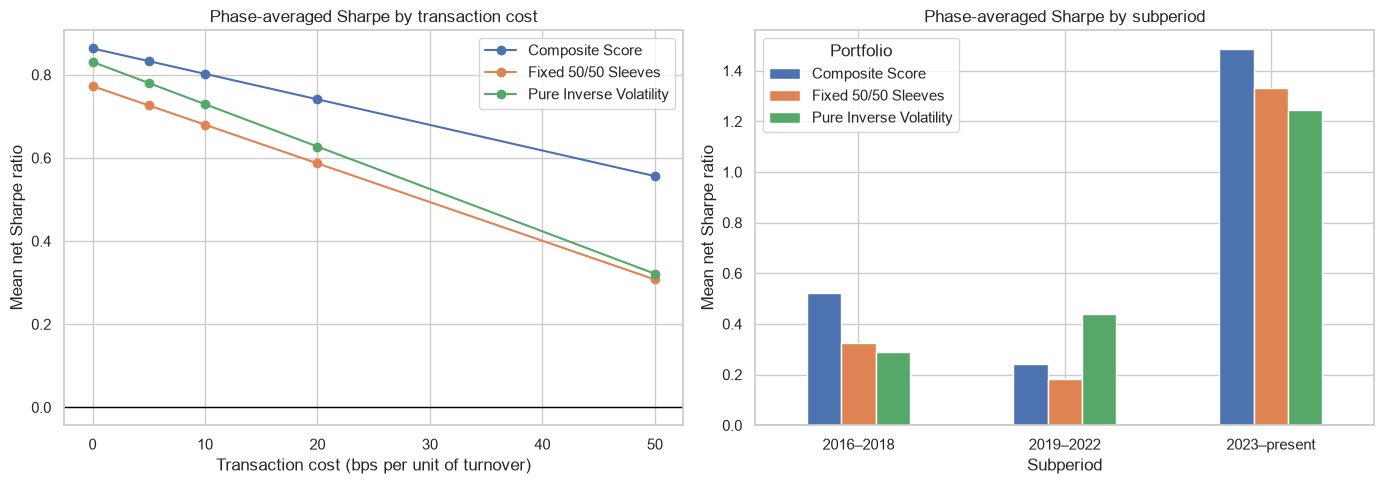

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)


for portfolio_name in CANDIDATE_ORDER:
    portfolio_cost_data = selected_cost_sensitivity.loc[
        selected_cost_sensitivity["portfolio"].eq(portfolio_name)
    ]

    axes[0].plot(
        portfolio_cost_data["transaction_cost_bps"],
        portfolio_cost_data["mean_net_sharpe"],
        marker="o",
        label=portfolio_name,
    )


axes[0].axhline(
    0.0,
    color="black",
    linewidth=1,
)

axes[0].set_title("Phase-averaged Sharpe by transaction cost")

axes[0].set_xlabel("Transaction cost (bps per unit of turnover)")

axes[0].set_ylabel("Mean net Sharpe ratio")

axes[0].legend()


subperiod_sharpe_table.plot(
    kind="bar",
    ax=axes[1],
)

axes[1].axhline(
    0.0,
    color="black",
    linewidth=1,
)

axes[1].set_title("Phase-averaged Sharpe by subperiod")

axes[1].set_xlabel("Subperiod")

axes[1].set_ylabel("Mean net Sharpe ratio")

axes[1].tick_params(
    axis="x",
    rotation=0,
)

axes[1].legend(
    title="Portfolio",
)


plt.tight_layout()
plt.show()

### 3.5 Robustness findings

#### 1. Transaction costs do not change the hierarchy

Composite Score has the highest phase-averaged return and Sharpe ratio at every tested cost assumption.

Even at 50 basis points per unit of turnover:

- Composite Score returns 10.0% annually with a mean Sharpe ratio of 0.56;
- Fixed 50/50 returns 3.8% with a Sharpe ratio of 0.31; and
- Pure Inverse Volatility returns 4.0% with a Sharpe ratio of 0.32.

Every candidate remains profitable, and even the worst rebalance phase retains a positive Sharpe ratio. Composite Score's lower turnover gives it the strongest resistance to transaction-cost stress.

#### 2. Performance varies materially across regimes

All candidates produce positive phase-averaged returns and Sharpe ratios in all three subperiods. However, the magnitude varies substantially.

- **2016–2018:** Composite Score leads, with a 7.7% return and a 0.52 Sharpe ratio.
- **2019–2022:** Pure Inverse Volatility leads, with a 5.3% return and a 0.44 Sharpe ratio. Composite Score falls to a 2.9% return and a 0.24 Sharpe ratio.
- **2023–present:** all candidates strengthen sharply. Composite Score reaches a 41.5% return and a 1.48 Sharpe ratio.

Composite Score's worst 2019–2022 phase has a Sharpe ratio of only 0.05. Its positive full-sample result is therefore not solely a recent-period artefact, but much of its economic strength comes from the latest subperiod.

#### 3. Rolling performance is not uniformly positive

Composite Score has the highest median one-year phase-averaged Sharpe ratio, at 0.91, and a positive Sharpe ratio in 75.6% of evaluated rolling windows.

Nevertheless, every candidate has:

- a negative 10th-percentile rolling Sharpe ratio;
- a negative minimum rolling Sharpe ratio; and
- periods in which even the phase-averaged result is materially weak.

Pure Inverse Volatility has the least adverse lower tail:

- 10th-percentile rolling Sharpe: −0.48;
- minimum rolling Sharpe: −1.13; and
- positive worst-offset fraction: 71.4%.

This is modestly stronger than the corresponding downside stability of Composite Score.

#### 4. Decision implication

Composite Score retains the strongest upside, cost resilience and median rolling performance. Pure Inverse Volatility remains the strongest defensive alternative because it performs best in the weak 2019–2022 regime and has the least adverse lower tail across rolling windows.

The evidence does not support describing any candidate as consistently strong across all regimes. The final strategy conclusion must therefore combine Composite Score's economic lead with explicit acknowledgement of its temporal instability and dependence on the strong post-2022 period.

## 4. Implementability and current risk state

The final implementation decision must distinguish two questions:

### 4.1 Can the strategy be implemented?

This is assessed using:

- turnover magnitude and concentration;
- transaction costs;
- liquidity-data coverage;
- security-level trade capacity; and
- missing-return exposure.

### 4.2 Is its current risk profile acceptable?

This is assessed using:

- holdings-implied beta;
- realised volatility and drawdown;
- sector exposure;
- beta-contribution concentration; and
- recent return-contribution concentration.

Historical implementability evidence affects candidate eligibility. The latest monitoring state affects interpretation and limitations, but does not trigger retrospective re-optimisation.

### 4.3 Turnover and capacity scorecard

In [15]:
selected_turnover_evidence = robustness_turnover.loc[
    selected_configuration_mask(robustness_turnover)
].copy()


if len(selected_turnover_evidence) != len(CANDIDATE_ORDER):
    raise ValueError("Incomplete selected-configuration " "turnover evidence.")


if len(selected_capacity_evidence) != len(CANDIDATE_ORDER):
    raise ValueError("Incomplete selected-configuration " "capacity evidence.")


turnover_expected_offsets = selected_turnover_evidence["portfolio"].map(
    selected_frequency_lookup
)


capacity_expected_offsets = selected_capacity_evidence["portfolio"].map(
    selected_frequency_lookup
)


if not selected_turnover_evidence["offset_count"].eq(turnover_expected_offsets).all():
    raise ValueError("Turnover evidence has an unexpected " "number of offsets.")


if not selected_capacity_evidence["offset_count"].eq(capacity_expected_offsets).all():
    raise ValueError("Capacity evidence has an unexpected " "number of offsets.")


IMPLEMENTABILITY_CAPACITY_COLUMNS = [
    "portfolio",
    "minimum_adv_coverage",
    "median_fifth_percentile_capacity_usd",
    "worst_phase_fifth_percentile_capacity_usd",
    "median_capacity_usd",
    "worst_historical_capacity_usd",
]


implementability_scorecard = selected_turnover_evidence.merge(
    selected_capacity_evidence[IMPLEMENTABILITY_CAPACITY_COLUMNS],
    on="portfolio",
    how="left",
    validate="one_to_one",
)


CAPACITY_COLUMNS_USD = [
    "median_fifth_percentile_capacity_usd",
    "worst_phase_fifth_percentile_capacity_usd",
    "median_capacity_usd",
    "worst_historical_capacity_usd",
]


for column in CAPACITY_COLUMNS_USD:
    implementability_scorecard[
        column.replace(
            "_usd",
            "_usd_millions",
        )
    ] = (
        implementability_scorecard[column] / 1_000_000.0
    )


implementability_scorecard = (
    implementability_scorecard.drop(columns=CAPACITY_COLUMNS_USD)
    .set_index("portfolio")
    .reindex(CANDIDATE_ORDER)
    .reset_index()
)


if (
    implementability_scorecard["minimum_adv_coverage"]
    .lt(1.0 - ASSESSMENT_TOLERANCE)
    .any()
):
    raise ValueError(
        "At least one selected implementation " "has incomplete ADV coverage."
    )


IMPLEMENTABILITY_DISPLAY_COLUMNS = [
    "portfolio",
    "rebalance_frequency",
    "mean_daily_turnover",
    "mean_annualised_turnover",
    "median_rebalance_turnover",
    "median_p95_rebalance_turnover",
    "worst_phase_p95_rebalance_turnover",
    "worst_single_day_turnover",
    "worst_maximum_21_day_turnover",
    "minimum_adv_coverage",
    "median_fifth_percentile_capacity_usd_millions",
    "worst_phase_fifth_percentile_capacity_usd_millions",
    "median_capacity_usd_millions",
    "worst_historical_capacity_usd_millions",
]


display(implementability_scorecard[IMPLEMENTABILITY_DISPLAY_COLUMNS].round(4))

,portfolio,rebalance_frequency,mean_daily_turnover,mean_annualised_turnover,median_rebalance_turnover,median_p95_rebalance_turnover,worst_phase_p95_rebalance_turnover,worst_single_day_turnover,worst_maximum_21_day_turnover,minimum_adv_coverage,median_fifth_percentile_capacity_usd_millions,worst_phase_fifth_percentile_capacity_usd_millions,median_capacity_usd_millions,worst_historical_capacity_usd_millions
0,Composite Score,21,0.0511,12.8750,1.0558,1.5619,1.6741,2.0860,2.0860,1.0,27.4233,24.7719,52.4225,7.8914
1,Fixed 50/50 Sleeves,10,0.0617,15.5540,0.6058,0.8892,0.9359,1.3304,3.2722,1.0,42.2825,40.1749,96.9015,5.5900
2,Pure Inverse Volatility,10,0.0655,16.5153,0.6362,0.9458,0.9871,1.3304,3.2851,1.0,41.2661,38.3357,92.7983,5.4438


### 4.4 Extract latest monitoring states

In [16]:
def latest_candidate_rows(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    latest_rows = (
        dataframe.loc[dataframe["portfolio"].isin(CANDIDATE_ORDER)]
        .sort_values(
            [
                "portfolio",
                "date",
            ]
        )
        .groupby(
            "portfolio",
            sort=False,
        )
        .tail(1)
        .set_index("portfolio")
        .reindex(CANDIDATE_ORDER)
        .reset_index()
    )

    if len(latest_rows) != len(CANDIDATE_ORDER):
        raise ValueError("Latest monitoring state is " "missing a candidate.")

    return latest_rows


latest_performance_rows = latest_candidate_rows(monitoring_performance_risk)

latest_beta_rows = latest_candidate_rows(monitoring_beta)

latest_concentration_rows = latest_candidate_rows(monitoring_concentration)

latest_implementation_rows = latest_candidate_rows(monitoring_implementation)


latest_state_date_audit = pd.DataFrame(
    {
        "performance": (latest_performance_rows.set_index("portfolio")["date"]),
        "beta": (latest_beta_rows.set_index("portfolio")["date"]),
        "concentration": (latest_concentration_rows.set_index("portfolio")["date"]),
        "implementation": (latest_implementation_rows.set_index("portfolio")["date"]),
    }
).reindex(CANDIDATE_ORDER)


latest_state_date_audit["dates_align"] = latest_state_date_audit.nunique(axis=1).eq(1)


display(latest_state_date_audit)


if not latest_state_date_audit["dates_align"].all():
    raise ValueError("Latest monitoring dates do not " "align within each portfolio.")

,performance,beta,concentration,implementation,dates_align
portfolio,,,,,
Composite Score,2026-07-01,2026-07-01,2026-07-01,2026-07-01,True
Fixed 50/50 Sleeves,2026-07-01,2026-07-01,2026-07-01,2026-07-01,True
Pure Inverse Volatility,2026-07-01,2026-07-01,2026-07-01,2026-07-01,True


### 4.5 Current risk and implementation snapshot

In [17]:
latest_status_rows = monitoring_latest_overview.loc[
    monitoring_latest_overview["entity_type"].eq("Portfolio")
].rename(
    columns={
        "entity": "portfolio",
    }
)


current_risk_snapshot = (
    latest_beta_rows[
        [
            "portfolio",
            "date",
            "holdings_market_beta",
            "holdings_long_beta_contribution",
            "holdings_short_beta_contribution",
            "realised_gross_beta_126",
            "beta_coverage",
        ]
    ]
    .rename(
        columns={
            "date": "latest_date",
        }
    )
    .merge(
        latest_performance_rows[
            [
                "portfolio",
                "annualised_volatility_126",
                "rolling_sharpe_252",
                "drawdown",
                "maximum_drawdown_252",
            ]
        ],
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .merge(
        latest_concentration_rows[
            [
                "portfolio",
                "effective_position_count",
                "effective_sector_count",
                "largest_absolute_sector_net_exposure",
                "effective_beta_contributor_count",
                "top_five_absolute_beta_contribution_share",
                "top_five_contributor_share_63",
                "effective_contribution_sector_count_63",
            ]
        ],
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .merge(
        latest_implementation_rows[
            [
                "portfolio",
                "annualised_turnover_63",
                "largest_trade_weight_63",
                "minimum_trade_capacity_1pct_usd_63",
                "maximum_missing_return_weight_63",
            ]
        ],
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .merge(
        latest_status_rows[
            [
                "portfolio",
                "overall_status",
                "market_risk_status",
                "concentration_status",
                "implementation_status",
            ]
        ],
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
)


current_risk_snapshot["minimum_trade_capacity_1pct_usd_millions_63"] = (
    current_risk_snapshot["minimum_trade_capacity_1pct_usd_63"] / 1_000_000.0
)


current_risk_snapshot = (
    current_risk_snapshot.drop(columns=("minimum_trade_capacity_1pct_usd_63"))
    .set_index("portfolio")
    .reindex(CANDIDATE_ORDER)
    .reset_index()
)


CURRENT_RISK_DISPLAY_COLUMNS = [
    "portfolio",
    "latest_date",
    "holdings_market_beta",
    "holdings_long_beta_contribution",
    "holdings_short_beta_contribution",
    "annualised_volatility_126",
    "drawdown",
    "effective_position_count",
    "effective_sector_count",
    "largest_absolute_sector_net_exposure",
    "top_five_absolute_beta_contribution_share",
    "top_five_contributor_share_63",
    "effective_contribution_sector_count_63",
    "annualised_turnover_63",
    "largest_trade_weight_63",
    "minimum_trade_capacity_1pct_usd_millions_63",
    "maximum_missing_return_weight_63",
    "overall_status",
    "market_risk_status",
    "concentration_status",
    "implementation_status",
]


display(current_risk_snapshot[CURRENT_RISK_DISPLAY_COLUMNS].round(4))

,portfolio,latest_date,holdings_market_beta,holdings_long_beta_contribution,holdings_short_beta_contribution,annualised_volatility_126,drawdown,effective_position_count,effective_sector_count,largest_absolute_sector_net_exposure,top_five_absolute_beta_contribution_share,top_five_contributor_share_63,effective_contribution_sector_count_63,annualised_turnover_63,largest_trade_weight_63,minimum_trade_capacity_1pct_usd_millions_63,maximum_missing_return_weight_63,overall_status,market_risk_status,concentration_status,implementation_status
0,Composite Score,2026-07-01,1.8273,1.8712,-0.0440,0.3675,-0.0976,39.7621,5.3959,0.6794,0.3798,0.2906,3.2127,10.7407,0.0548,58.4221,0.0,WARNING,WARNING,WARNING,PASS
1,Fixed 50/50 Sleeves,2026-07-01,1.4100,1.6114,-0.2014,0.3010,-0.0965,45.3945,5.8177,0.4491,0.4192,0.3467,3.2069,13.2630,0.0467,167.6619,0.0,WARNING,WARNING,WARNING,PASS
2,Pure Inverse Volatility,2026-07-01,1.4098,1.6116,-0.2018,0.3018,-0.0966,45.4281,5.8151,0.4488,0.4191,0.3407,3.1453,14.0608,0.0469,154.7008,0.0,WARNING,WARNING,WARNING,PASS


### 4.6 Active decision-relevant warnings

In [18]:
current_portfolio_warnings = (
    monitoring_diagnostic_flags.loc[
        monitoring_diagnostic_flags["entity_type"].eq("Portfolio")
        & monitoring_diagnostic_flags["status"].ne("PASS")
    ][
        [
            "entity",
            "category",
            "diagnostic",
            "latest_value",
            "threshold_value",
            "historical_percentile",
            "status",
        ]
    ]
    .rename(
        columns={
            "entity": "portfolio",
        }
    )
    .sort_values(
        [
            "portfolio",
            "category",
            "diagnostic",
        ]
    )
    .reset_index(drop=True)
)


display(current_portfolio_warnings.round(4))

,portfolio,category,diagnostic,latest_value,threshold_value,historical_percentile,status
0,Composite Score,Concentration,Effective 63-day contribution sectors,3.2127,4.2169,0.0004,WARNING
1,Composite Score,Concentration,Largest absolute sector net exposure,0.6794,0.5202,0.9958,WARNING
2,Composite Score,Concentration,Top-five 63-day security-contribution share,0.2906,0.2576,1.0000,WARNING
3,Composite Score,Concentration,Top-five absolute beta-contribution share,0.3798,0.3167,0.9962,WARNING
4,Composite Score,Market risk,Absolute holdings-implied beta,1.8273,1.3755,0.9954,WARNING
5,Composite Score,Market risk,Annualised volatility (126 days),0.3675,0.2757,1.0000,WARNING
6,Fixed 50/50 Sleeves,Concentration,Effective 63-day contribution sectors,3.2069,4.1588,0.0008,WARNING
7,Fixed 50/50 Sleeves,Concentration,Largest absolute sector net exposure,0.4491,0.4204,0.9503,WARNING
8,Fixed 50/50 Sleeves,Concentration,Top-five 63-day security-contribution share,0.3467,0.2886,1.0000,WARNING
9,Fixed 50/50 Sleeves,Concentration,Top-five absolute beta-contribution share,0.4192,0.3596,0.9860,WARNING


### 4.7 Implementability and risk findings

#### 1. All candidates pass the implementation gate

All three implementations have:

- complete lagged ADV coverage;
- no current missing-return exposure;
- positive capacity at every evaluated trade event;
- transaction costs consistent with the assumed 10-basis-point model; and
- an overall implementation status of **PASS**.

No candidate should be excluded on operational grounds.

#### 2. Composite Score trades less often but more heavily

Composite Score has the lowest phase-averaged daily turnover:

- Composite Score: 5.1%;
- Fixed 50/50: 6.2%; and
- Pure Inverse Volatility: 6.6%.

Its lower trading frequency reduces cumulative turnover and transaction-cost sensitivity. However, each rebalance is larger:

- median rebalance turnover is 105.6%; and
- the worst single-day turnover is 208.6%.

The sleeve portfolios rebalance more frequently but distribute their trades across smaller individual events.

#### 3. Capacity is adequate but implementation-dependent

At a 1% participation limit, worst-phase fifth-percentile capacity is:

- $24.8 million for Composite Score;
- $40.2 million for Fixed 50/50; and
- $38.3 million for Pure Inverse Volatility.

The sleeve portfolios therefore have stronger typical conservative capacity. Composite Score nevertheless has the highest worst historical capacity estimate, at $7.9 million, compared with approximately $5.5 million for the sleeve portfolios.

These figures support implementability at modest strategy scale, but they should not be treated as fixed capital limits. They depend on historical liquidity, synchronous execution and the simplified participation model.

#### 4. Current market exposure is elevated

All three portfolios are in a historically unusual high-beta and high-volatility state.

Composite Score has the largest absolute exposure:

- holdings-implied beta: 1.83;
- annualised 126-day volatility: 36.7%; and
- largest absolute sector net exposure: 67.9% of NAV.

Its long-side beta contribution is 1.87, while its short side offsets only −0.04. The portfolio is therefore long/short by capital construction but currently provides very little market-beta neutrality.

The sleeve portfolios have lower absolute beta, at approximately 1.41, and lower volatility, at approximately 30.1%. These values are nevertheless extreme relative to their own histories.

#### 5. Diversification is weaker than position counts suggest

The portfolios hold approximately 40–45 effective positions, but current risk and realised performance are much more concentrated:

- the five largest beta contributors account for 38%–42% of absolute beta contribution;
- the five largest security contributors account for 29%–35% of recent absolute return contribution; and
- only about three effective sectors drive trailing realised contributions.

This distinction is important: nominal security diversification does not imply diversified economic exposure.

#### 6. Decision implication

Implementation evidence supports all three candidates. Composite Score benefits from lower average turnover and greater cost resilience, while the sleeve portfolios provide higher typical capacity and smaller individual rebalance events.

The latest **WARNING** state does not invalidate the strategies or indicate signal failure. It does show that current performance is associated with unusually high beta, volatility and concentration. These exposures must be treated as a limitation of the current specification rather than as diversified alpha.

## 5. Candidate eligibility and evidence matrix

The final assessment follows two stages:

### 5.1 Eligibility

A candidate must pass the frozen-specification, data-integrity and implementation gates.

### 5.2 Comparative judgement

Eligible candidates are then compared across:

- performance;
- phase, cost and temporal robustness;
- drawdown and lower-tail stability;
- turnover and capacity;
- current market and concentration risk;
- transparency; and
- complexity.

No arbitrary weighted score is assigned. The evidence matrix preserves the trade-offs and supports an explicit research judgement.

### 5.3 Eligibility gates

In [19]:
portfolio_status_rows = latest_status_rows[
    [
        "portfolio",
        "breaches",
        "unavailable",
        "implementation_status",
    ]
]


candidate_eligibility = (
    EXPECTED_IMPLEMENTATIONS.merge(
        implementability_scorecard[
            [
                "portfolio",
                "minimum_adv_coverage",
            ]
        ],
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .merge(
        current_risk_snapshot[
            [
                "portfolio",
                "maximum_missing_return_weight_63",
            ]
        ],
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .merge(
        portfolio_status_rows,
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
)


candidate_eligibility["frozen_specification_passes"] = True

candidate_eligibility["sample_alignment_passes"] = True

candidate_eligibility["adv_coverage_passes"] = candidate_eligibility[
    "minimum_adv_coverage"
].ge(1.0 - ASSESSMENT_TOLERANCE)

candidate_eligibility["missing_returns_passes"] = candidate_eligibility[
    "maximum_missing_return_weight_63"
].le(ASSESSMENT_TOLERANCE)

candidate_eligibility["implementation_status_passes"] = candidate_eligibility[
    "implementation_status"
].eq("PASS")

candidate_eligibility["structural_diagnostics_pass"] = candidate_eligibility[
    "breaches"
].eq(0) & candidate_eligibility["unavailable"].eq(0)


ELIGIBILITY_GATE_COLUMNS = [
    "frozen_specification_passes",
    "sample_alignment_passes",
    "adv_coverage_passes",
    "missing_returns_passes",
    "implementation_status_passes",
    "structural_diagnostics_pass",
]


candidate_eligibility["eligible"] = candidate_eligibility[ELIGIBILITY_GATE_COLUMNS].all(
    axis=1
)


candidate_eligibility = (
    candidate_eligibility.set_index("portfolio").reindex(CANDIDATE_ORDER).reset_index()
)


display(
    candidate_eligibility[
        [
            "portfolio",
            "role",
            *ELIGIBILITY_GATE_COLUMNS,
            "eligible",
        ]
    ]
)


if not candidate_eligibility["eligible"].all():
    raise ValueError("At least one frozen candidate fails an eligibility gate.")

,portfolio,role,frozen_specification_passes,sample_alignment_passes,adv_coverage_passes,missing_returns_passes,implementation_status_passes,structural_diagnostics_pass,eligible
0,Composite Score,Primary specification,True,True,True,True,True,True,True
1,Fixed 50/50 Sleeves,Transparent sleeve benchmark,True,True,True,True,True,True,True
2,Pure Inverse Volatility,Risk-based sleeve benchmark,True,True,True,True,True,True,True


### 5.4 Rejected optimisation evidence

In [20]:
mvo_diagnostic_lookup = mvo_forecast_diagnostics.set_index("metric")["value"]


REQUIRED_MVO_DIAGNOSTICS = [
    "allocations",
    "boundary_solution_fraction",
    "estimated_vs_realised_spread_pearson",
    "estimated_vs_realised_spread_spearman",
    "return_ranking_hit_rate",
    "positive_mvo_minus_equal_fraction",
    "mean_mvo_minus_equal_bps_per_period",
    "diagnostic_mvo_annualised_return",
    "diagnostic_equal_weight_annualised_return",
]


missing_mvo_diagnostics = set(REQUIRED_MVO_DIAGNOSTICS) - set(
    mvo_diagnostic_lookup.index
)


if missing_mvo_diagnostics:
    raise KeyError("Missing MVO diagnostics: " f"{sorted(missing_mvo_diagnostics)}")


mvo_decision_diagnostics = (
    mvo_diagnostic_lookup.loc[REQUIRED_MVO_DIAGNOSTICS].rename("value").to_frame()
)


MVO_SHRINKAGE_DISPLAY_COLUMNS = [
    "mvo_intensity",
    "net_annualised_return",
    "net_sharpe",
    "net_max_drawdown",
    "average_daily_turnover",
    "net_return_minus_50_50",
    "net_sharpe_minus_50_50",
]


mvo_shrinkage_decision_evidence = (
    mvo_shrinkage_sensitivity[MVO_SHRINKAGE_DISPLAY_COLUMNS]
    .sort_values("mvo_intensity")
    .reset_index(drop=True)
)


display(mvo_decision_diagnostics.round(4))

display(mvo_shrinkage_decision_evidence.round(4))

,value
metric,
allocations,501.0000
boundary_solution_fraction,0.6168
estimated_vs_realised_spread_pearson,-0.0678
estimated_vs_realised_spread_spearman,0.0084
return_ranking_hit_rate,0.4830
positive_mvo_minus_equal_fraction,0.4770
mean_mvo_minus_equal_bps_per_period,-14.2651
diagnostic_mvo_annualised_return,0.0473
diagnostic_equal_weight_annualised_return,0.1345


,mvo_intensity,net_annualised_return,net_sharpe,net_max_drawdown,average_daily_turnover,net_return_minus_50_50,net_sharpe_minus_50_50
0,0.00,0.1134,0.7151,-0.2566,0.0873,0.0000,0.0000
1,0.25,0.0911,0.5969,-0.2995,0.0946,-0.0223,-0.1182
2,0.50,0.0673,0.4574,-0.4155,0.1038,-0.0461,-0.2577
3,0.75,0.0424,0.3149,-0.5348,0.1137,-0.0710,-0.4002
4,1.00,0.0163,0.1822,-0.6347,0.1247,-0.0971,-0.5329


### 5.5 Construct quantitative decision evidence

In [21]:
subperiod_downside_summary = (
    selected_subperiod_robustness.groupby(
        "portfolio",
        sort=False,
    )
    .agg(
        weakest_subperiod_mean_return=(
            "mean_net_annualised_return",
            "min",
        ),
        weakest_subperiod_mean_sharpe=(
            "mean_net_sharpe",
            "min",
        ),
        weakest_subperiod_worst_phase_sharpe=(
            "minimum_net_sharpe",
            "min",
        ),
    )
    .reset_index()
)


QUANTITATIVE_HEADLINE_COLUMNS = [
    "portfolio",
    "net_annualised_return",
    "net_annualised_volatility",
    "net_sharpe",
    "net_maximum_drawdown",
    "mean_net_annualised_return",
    "minimum_net_annualised_return",
    "mean_net_sharpe",
    "minimum_net_sharpe",
    "annualised_return_cost_drag",
]


QUANTITATIVE_ROLLING_COLUMNS = [
    "portfolio",
    "median_phase_averaged_sharpe",
    "tenth_percentile_phase_averaged_sharpe",
    "minimum_phase_averaged_sharpe",
    "positive_phase_averaged_fraction",
    "positive_worst_offset_fraction",
]


QUANTITATIVE_IMPLEMENTATION_COLUMNS = [
    "portfolio",
    "mean_daily_turnover",
    "worst_single_day_turnover",
    "worst_phase_fifth_percentile_capacity_usd_millions",
    "worst_historical_capacity_usd_millions",
]


QUANTITATIVE_RISK_COLUMNS = [
    "portfolio",
    "holdings_market_beta",
    "annualised_volatility_126",
    "largest_absolute_sector_net_exposure",
    "top_five_absolute_beta_contribution_share",
    "top_five_contributor_share_63",
    "effective_contribution_sector_count_63",
]


quantitative_decision_evidence = (
    candidate_scorecard[QUANTITATIVE_HEADLINE_COLUMNS]
    .merge(
        subperiod_downside_summary,
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .merge(
        selected_rolling_stability[QUANTITATIVE_ROLLING_COLUMNS],
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .merge(
        implementability_scorecard[QUANTITATIVE_IMPLEMENTATION_COLUMNS],
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .merge(
        current_risk_snapshot[QUANTITATIVE_RISK_COLUMNS],
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .set_index("portfolio")
    .reindex(CANDIDATE_ORDER)
    .reset_index()
)


if quantitative_decision_evidence.drop(columns="portfolio").isna().any().any():
    raise ValueError("Quantitative decision evidence " "contains missing values.")


QUANTITATIVE_DECISION_DISPLAY_COLUMNS = [
    "portfolio",
    "net_annualised_return",
    "net_sharpe",
    "net_annualised_volatility",
    "net_maximum_drawdown",
    "minimum_net_sharpe",
    "weakest_subperiod_mean_sharpe",
    "tenth_percentile_phase_averaged_sharpe",
    "positive_phase_averaged_fraction",
    "mean_daily_turnover",
    "worst_phase_fifth_percentile_capacity_usd_millions",
    "holdings_market_beta",
    "annualised_volatility_126",
    "largest_absolute_sector_net_exposure",
]


display(quantitative_decision_evidence[QUANTITATIVE_DECISION_DISPLAY_COLUMNS].round(4))

,portfolio,net_annualised_return,net_sharpe,net_annualised_volatility,net_maximum_drawdown,minimum_net_sharpe,weakest_subperiod_mean_sharpe,tenth_percentile_phase_averaged_sharpe,positive_phase_averaged_fraction,mean_daily_turnover,worst_phase_fifth_percentile_capacity_usd_millions,holdings_market_beta,annualised_volatility_126,largest_absolute_sector_net_exposure
0,Composite Score,0.1613,0.8128,0.2117,-0.2924,0.7013,0.2409,-0.5781,0.7559,0.0511,24.7719,1.8273,0.3675,0.6794
1,Fixed 50/50 Sleeves,0.1084,0.6983,0.1677,-0.2568,0.6238,0.1845,-0.6228,0.7089,0.0617,40.1749,1.4100,0.3010,0.4491
2,Pure Inverse Volatility,0.1096,0.7215,0.1625,-0.2177,0.6608,0.2895,-0.4791,0.7517,0.0655,38.3357,1.4098,0.3018,0.4488


### 5.6 Qualitative evidence matrix

In [22]:
qualitative_decision_matrix = pd.DataFrame(
    [
        {
            "portfolio": "Composite Score",
            "performance": ("Highest return and candidate " "Sharpe ratio"),
            "robustness": (
                "Cost leader; leads two of three " "subperiods; weaker in 2019–2022"
            ),
            "downside_profile": (
                "Highest volatility and larger "
                "drawdown; weaker rolling lower "
                "tail than Pure Inverse Volatility"
            ),
            "implementation": (
                "Lowest average turnover; larger "
                "rebalance events; adequate but "
                "lower typical capacity"
            ),
            "current_risk": ("Highest beta, volatility and " "sector imbalance"),
            "transparency": (
                "Direct security-level composite " "ranking with attributable factors"
            ),
            "complexity": "Moderate",
            "provisional_role": ("Primary implementation"),
        },
        {
            "portfolio": "Fixed 50/50 Sleeves",
            "performance": ("Lowest return and candidate " "Sharpe ratio"),
            "robustness": (
                "Positive across costs, phases " "and subperiods; no comparative lead"
            ),
            "downside_profile": ("Lower volatility and drawdown " "than Composite"),
            "implementation": (
                "Higher average turnover; smaller "
                "rebalance events; strongest "
                "typical capacity"
            ),
            "current_risk": (
                "Lower absolute beta than " "Composite but historically elevated"
            ),
            "transparency": (
                "Explicit equal allocation between " "the two factor sleeves"
            ),
            "complexity": "Low",
            "provisional_role": ("Transparent benchmark"),
        },
        {
            "portfolio": ("Pure Inverse Volatility"),
            "performance": ("Slightly exceeds Fixed 50/50; " "below Composite"),
            "robustness": (
                "Best in 2019–2022 and strongest " "rolling lower-tail stability"
            ),
            "downside_profile": (
                "Lowest full-sample volatility " "and least severe drawdown"
            ),
            "implementation": (
                "Highest average turnover; smaller "
                "rebalance events; strong typical "
                "capacity"
            ),
            "current_risk": (
                "Lower absolute beta than Composite " "but historically elevated"
            ),
            "transparency": (
                "Rule-based sleeve weights derived " "from estimated volatility"
            ),
            "complexity": "Low to moderate",
            "provisional_role": ("Risk-based benchmark"),
        },
    ]
)


qualitative_decision_matrix = qualitative_decision_matrix.set_index(
    "portfolio"
).reindex(CANDIDATE_ORDER)


display(qualitative_decision_matrix)

,performance,robustness,downside_profile,implementation,current_risk,transparency,complexity,provisional_role
portfolio,,,,,,,,
Composite Score,Highest return and candidate Sharpe ratio,Cost leader; leads two of three subperiods; we...,Highest volatility and larger drawdown; weaker...,Lowest average turnover; larger rebalance even...,"Highest beta, volatility and sector imbalance",Direct security-level composite ranking with a...,Moderate,Primary implementation
Fixed 50/50 Sleeves,Lowest return and candidate Sharpe ratio,"Positive across costs, phases and subperiods; ...",Lower volatility and drawdown than Composite,Higher average turnover; smaller rebalance eve...,Lower absolute beta than Composite but histori...,Explicit equal allocation between the two fact...,Low,Transparent benchmark
Pure Inverse Volatility,Slightly exceeds Fixed 50/50; below Composite,Best in 2019–2022 and strongest rolling lower-...,Lowest full-sample volatility and least severe...,Highest average turnover; smaller rebalance ev...,Lower absolute beta than Composite but histori...,Rule-based sleeve weights derived from estimat...,Low to moderate,Risk-based benchmark


## 6. Final implementation decision

### 6.1 Candidate eligibility

All three frozen candidates pass every eligibility gate:

- specifications are frozen and samples align;
- liquidity coverage is complete;
- no missing-return exposure is active;
- implementation diagnostics pass; and
- no structural breach or unavailable diagnostic is present.

The final choice is therefore comparative rather than exclusionary.

### 6.2 Primary implementation — Composite Score

**Composite Score, rebalanced every 21 trading days, is retained as the primary strategy.**

The decision is supported by:

- the highest whole-sample return and candidate Sharpe ratio;
- the highest phase-averaged return and Sharpe ratio;
- positive results under every tested rebalance phase;
- leadership at every tested transaction-cost assumption;
- the highest median rolling Sharpe ratio;
- positive performance in every predefined subperiod; and
- the lowest average turnover.

Its offset-zero result is close to its phase average, so the selected implementation does not depend materially on a favourable rebalance date.

The selection is nevertheless qualified. Composite Score has the highest volatility and beta, a larger drawdown than the sleeve portfolios, weaker lower-tail stability than Pure Inverse Volatility and substantial dependence on the strong post-2022 period.

### 6.3 Risk-based alternative — Pure Inverse Volatility

**Pure Inverse Volatility is retained as the principal defensive alternative.**

It provides:

- the lowest whole-sample volatility;
- the least severe maximum drawdown;
- the strongest result in 2019–2022;
- the least adverse lower tail of rolling Sharpe ratios; and
- strong typical capacity.

It modestly outperforms Fixed 50/50 while preserving a simple rule-based allocation. It is therefore the most relevant alternative when downside stability is prioritised over maximum historical return.

### 6.4 Transparent benchmark — Fixed 50/50 Sleeves

**Fixed 50/50 Sleeves is retained as the transparent allocation benchmark.**

It does not lead the other candidates on historical performance or defensive stability. Its value is interpretive:

- sleeve weights are explicit and constant;
- factor contributions are easy to explain;
- no estimated allocation parameter is required; and
- it provides a clean reference for judging whether risk-based weighting adds value.

### 6.5 Rejection of maximum-Sharpe MVO

Maximum-Sharpe MVO remains outside the candidate set.

Its expected-return forecasts show no reliable allocation signal:

- 61.7% of solutions lie on a boundary;
- estimated and realised sleeve-return spreads are effectively uncorrelated;
- the return-ranking hit rate is 48.3%;
- MVO underperforms equal weighting by 14.3 basis points per allocation period on average; and
- diagnostic annualised return is 4.7%, versus 13.5% for equal weighting.

Increasing MVO intensity monotonically reduces return and Sharpe ratio, deepens drawdowns and increases turnover. The additional estimation complexity is therefore unsupported by realised evidence.

### 6.6 Final hierarchy

The hierarchy is based on distinct research roles rather than a claim that one portfolio dominates on every dimension:

1. **Composite Score:** primary implementation;
2. **Pure Inverse Volatility:** defensive risk-based alternative; and
3. **Fixed 50/50 Sleeves:** transparent allocation benchmark.

In [23]:
FINAL_HIERARCHY_ORDER = [
    "Composite Score",
    "Pure Inverse Volatility",
    "Fixed 50/50 Sleeves",
]


final_strategy_hierarchy = pd.DataFrame(
    [
        {
            "decision_order": 1,
            "portfolio": "Composite Score",
            "rebalance_frequency": 21,
            "rebalance_offset": 0,
            "transaction_cost_bps": 10.0,
            "final_role": ("Primary implementation"),
            "decision_status": "Selected",
            "selection_rationale": (
                "Strongest historical return, "
                "candidate Sharpe, cost resilience "
                "and median rolling performance"
            ),
            "principal_limitation": (
                "Highest beta, volatility and "
                "sector concentration; substantial "
                "post-2022 performance dependence"
            ),
        },
        {
            "decision_order": 2,
            "portfolio": ("Pure Inverse Volatility"),
            "rebalance_frequency": 10,
            "rebalance_offset": 0,
            "transaction_cost_bps": 10.0,
            "final_role": ("Defensive risk-based alternative"),
            "decision_status": ("Retained benchmark"),
            "selection_rationale": (
                "Lowest volatility and drawdown, "
                "best 2019–2022 result and strongest "
                "rolling lower-tail stability"
            ),
            "principal_limitation": (
                "Lower return than Composite and " "higher average turnover"
            ),
        },
        {
            "decision_order": 3,
            "portfolio": ("Fixed 50/50 Sleeves"),
            "rebalance_frequency": 10,
            "rebalance_offset": 0,
            "transaction_cost_bps": 10.0,
            "final_role": ("Transparent allocation benchmark"),
            "decision_status": ("Retained benchmark"),
            "selection_rationale": (
                "Simplest and most transparent " "sleeve allocation"
            ),
            "principal_limitation": (
                "No comparative performance or " "defensive advantage"
            ),
        },
    ]
)


if final_strategy_hierarchy["portfolio"].tolist() != FINAL_HIERARCHY_ORDER:
    raise ValueError("Unexpected final hierarchy.")


display(final_strategy_hierarchy)

,decision_order,portfolio,rebalance_frequency,rebalance_offset,transaction_cost_bps,final_role,decision_status,selection_rationale,principal_limitation
0,1,Composite Score,21,0,10.0,Primary implementation,Selected,"Strongest historical return, candidate Sharpe,...","Highest beta, volatility and sector concentrat..."
1,2,Pure Inverse Volatility,10,0,10.0,Defensive risk-based alternative,Retained benchmark,"Lowest volatility and drawdown, best 2019–2022...",Lower return than Composite and higher average...
2,3,Fixed 50/50 Sleeves,10,0,10.0,Transparent allocation benchmark,Retained benchmark,Simplest and most transparent sleeve allocation,No comparative performance or defensive advantage


## 7. Risk-control decision and limitations

### 7.1 Decision for the current project

The researched implementations are retained without adding beta-neutrality or sector constraints.

This does not imply that the current exposures are desirable. It reflects research discipline:

- the latest high-beta and concentrated state has already been observed;
- control thresholds were not specified before inspecting it;
- adding constraints now would create another design and optimisation cycle; and
- any apparent improvement would be evaluated on the same sample that motivated the change.

The present strategy should therefore be described as a long/short factor portfolio, not as market-neutral or sector-neutral.

### 7.2 Future risk-control extension

Beta and sector controls are appropriate subjects for a separate extension. That study should:

1. specify controls before evaluating their performance;
2. test beta-targeted and sector-constrained variants separately;
3. preserve gross-exposure and turnover accounting;
4. include transaction costs, shorting frictions and capacity;
5. compare exposure reduction with lost factor efficacy; and
6. reserve new data or a forward period for validation.

The current unconstrained implementation should remain the reference specification so that any benefit from the controls can be measured honestly.

In [24]:
final_strategy_limitations = pd.DataFrame(
    [
        {
            "limitation_id": "L01",
            "category": "Validation",
            "limitation": (
                "The evaluated history is not a "
                "pristine holdout because research "
                "decisions were informed by the sample."
            ),
            "implication": (
                "Reported performance is research "
                "evidence, not an unbiased forecast."
            ),
        },
        {
            "limitation_id": "L02",
            "category": "Universe",
            "limitation": (
                "The large-cap universe is limited "
                "and may contain membership or "
                "survivorship effects."
            ),
            "implication": (
                "Results may not generalise to a " "point-in-time or broader universe."
            ),
        },
        {
            "limitation_id": "L03",
            "category": "Temporal stability",
            "limitation": (
                "Performance is materially stronger "
                "after 2022 than in earlier periods."
            ),
            "implication": (
                "Full-sample statistics overstate " "consistency across regimes."
            ),
        },
        {
            "limitation_id": "L04",
            "category": "Transaction costs",
            "limitation": (
                "Costs use a linear turnover model "
                "rather than security- and "
                "time-varying execution costs."
            ),
            "implication": ("Real execution drag may be nonlinear."),
        },
        {
            "limitation_id": "L05",
            "category": "Shorting",
            "limitation": (
                "Borrow availability, borrow fees, "
                "recalls and financing are not "
                "modelled fully."
            ),
            "implication": ("Net short-side performance may be " "overstated."),
        },
        {
            "limitation_id": "L06",
            "category": "Capacity",
            "limitation": (
                "Capacity is inferred from lagged ADV "
                "and a fixed participation limit."
            ),
            "implication": (
                "Capacity estimates are scenario " "indicators, not deployable limits."
            ),
        },
        {
            "limitation_id": "L07",
            "category": "Market exposure",
            "limitation": (
                "The portfolios have no explicit " "beta- or sector-neutrality control."
            ),
            "implication": (
                "Returns can contain substantial " "market and sector exposure."
            ),
        },
        {
            "limitation_id": "L08",
            "category": "Risk estimation",
            "limitation": (
                "Rolling beta, volatility and "
                "covariance estimates are noisy and "
                "backward-looking."
            ),
            "implication": (
                "Current exposure estimates are " "diagnostics rather than exact risks."
            ),
        },
        {
            "limitation_id": "L09",
            "category": "Benchmark",
            "limitation": (
                "SPY is long-only and is not exposure-"
                "matched to the candidate portfolios."
            ),
            "implication": (
                "Its return and Sharpe comparisons " "provide context, not attribution."
            ),
        },
        {
            "limitation_id": "L10",
            "category": "External validation",
            "limitation": (
                "No live, paper-trading or genuinely "
                "unseen forward period is available."
            ),
            "implication": (
                "Operational and predictive validity " "remain unconfirmed."
            ),
        },
    ]
)


display(final_strategy_limitations)

,limitation_id,category,limitation,implication
0,L01,Validation,The evaluated history is not a pristine holdou...,"Reported performance is research evidence, not..."
1,L02,Universe,The large-cap universe is limited and may cont...,Results may not generalise to a point-in-time ...
2,L03,Temporal stability,Performance is materially stronger after 2022 ...,Full-sample statistics overstate consistency a...
3,L04,Transaction costs,Costs use a linear turnover model rather than ...,Real execution drag may be nonlinear.
4,L05,Shorting,"Borrow availability, borrow fees, recalls and ...",Net short-side performance may be overstated.
5,L06,Capacity,Capacity is inferred from lagged ADV and a fix...,"Capacity estimates are scenario indicators, no..."
6,L07,Market exposure,The portfolios have no explicit beta- or secto...,Returns can contain substantial market and sec...
7,L08,Risk estimation,"Rolling beta, volatility and covariance estima...",Current exposure estimates are diagnostics rat...
8,L09,Benchmark,SPY is long-only and is not exposure-matched t...,Its return and Sharpe comparisons provide cont...
9,L10,External validation,"No live, paper-trading or genuinely unseen for...",Operational and predictive validity remain unc...


In [25]:
decision_metric_lookup = quantitative_decision_evidence.set_index("portfolio")

current_metric_lookup = current_risk_snapshot.set_index("portfolio")


final_strategy_claims = pd.DataFrame(
    [
        {
            "claim_id": "C01",
            "topic": "Primary strategy",
            "supported_claim": (
                "Composite Score was the strongest " "historical candidate."
            ),
            "evidence": (
                "Net annualised return "
                f"{decision_metric_lookup.loc['Composite Score', 'net_annualised_return']:.1%}; "
                "Sharpe "
                f"{decision_metric_lookup.loc['Composite Score', 'net_sharpe']:.2f}."
            ),
            "scope_guardrail": (
                "Do not present this as guaranteed " "future outperformance."
            ),
        },
        {
            "claim_id": "C02",
            "topic": "Phase robustness",
            "supported_claim": (
                "The selected Composite result does "
                "not depend on a single rebalance phase."
            ),
            "evidence": (
                "Worst-phase Sharpe "
                f"{decision_metric_lookup.loc['Composite Score', 'minimum_net_sharpe']:.2f}."
            ),
            "scope_guardrail": (
                "Phase robustness does not remove " "market-regime dependence."
            ),
        },
        {
            "claim_id": "C03",
            "topic": "Defensive alternative",
            "supported_claim": (
                "Pure Inverse Volatility provides " "the strongest defensive profile."
            ),
            "evidence": (
                "Full-sample volatility "
                f"{decision_metric_lookup.loc['Pure Inverse Volatility', 'net_annualised_volatility']:.1%}; "
                "maximum drawdown "
                f"{decision_metric_lookup.loc['Pure Inverse Volatility', 'net_maximum_drawdown']:.1%}."
            ),
            "scope_guardrail": ("It does not lead on full-sample return."),
        },
        {
            "claim_id": "C04",
            "topic": "Cost resilience",
            "supported_claim": (
                "All selected implementations remain "
                "profitable at the highest tested cost."
            ),
            "evidence": (
                "Phase-averaged annualised returns " "remain positive at 50 bps."
            ),
            "scope_guardrail": (
                "The cost model remains linear and "
                "does not model market impact fully."
            ),
        },
        {
            "claim_id": "C05",
            "topic": "Temporal stability",
            "supported_claim": (
                "Performance is positive but not " "uniform across historical regimes."
            ),
            "evidence": (
                "All subperiod mean Sharpes are "
                "positive, while rolling lower-tail "
                "Sharpes are negative."
            ),
            "scope_guardrail": (
                "Do not describe the strategy as " "consistently profitable."
            ),
        },
        {
            "claim_id": "C06",
            "topic": "Implementability",
            "supported_claim": (
                "The strategies appear implementable "
                "at modest scale under the modelled "
                "assumptions."
            ),
            "evidence": (
                "Complete ADV coverage, positive "
                "capacity and passing implementation "
                "diagnostics."
            ),
            "scope_guardrail": (
                "Capacity estimates are not hard " "deployable capital limits."
            ),
        },
        {
            "claim_id": "C07",
            "topic": "Current risk",
            "supported_claim": (
                "Current performance occurs in a " "high-beta and concentrated regime."
            ),
            "evidence": (
                "Composite holdings-implied beta "
                f"{current_metric_lookup.loc['Composite Score', 'holdings_market_beta']:.2f}; "
                "largest sector imbalance "
                f"{current_metric_lookup.loc['Composite Score', 'largest_absolute_sector_net_exposure']:.1%}."
            ),
            "scope_guardrail": (
                "Do not describe the strategy as " "market-neutral or sector-neutral."
            ),
        },
        {
            "claim_id": "C08",
            "topic": "MVO",
            "supported_claim": (
                "Maximum-Sharpe MVO added complexity "
                "without reliable realised benefit."
            ),
            "evidence": (
                "Forecast hit rate "
                f"{mvo_diagnostic_lookup['return_ranking_hit_rate']:.1%}; "
                "mean MVO-minus-equal return "
                f"{mvo_diagnostic_lookup['mean_mvo_minus_equal_bps_per_period']:.1f} "
                "bps per allocation period."
            ),
            "scope_guardrail": (
                "This rejects the tested estimator, "
                "not all possible optimisation methods."
            ),
        },
        {
            "claim_id": "C09",
            "topic": "Market comparison",
            "supported_claim": (
                "Composite slightly exceeds SPY's " "return but not its Sharpe ratio."
            ),
            "evidence": (
                f"SPY return {benchmark_summary['annualised_return']:.1%} "
                f"and Sharpe {benchmark_summary['sharpe_ratio']:.2f}."
            ),
            "scope_guardrail": (
                "SPY is contextual rather than an " "exposure-matched benchmark."
            ),
        },
    ]
)


display(final_strategy_claims)


,claim_id,topic,supported_claim,evidence,scope_guardrail
0,C01,Primary strategy,Composite Score was the strongest historical c...,Net annualised return 16.1%; Sharpe 0.81.,Do not present this as guaranteed future outpe...
1,C02,Phase robustness,The selected Composite result does not depend ...,Worst-phase Sharpe 0.70.,Phase robustness does not remove market-regime...
2,C03,Defensive alternative,Pure Inverse Volatility provides the strongest...,Full-sample volatility 16.3%; maximum drawdown...,It does not lead on full-sample return.
3,C04,Cost resilience,All selected implementations remain profitable...,Phase-averaged annualised returns remain posit...,The cost model remains linear and does not mod...
4,C05,Temporal stability,Performance is positive but not uniform across...,"All subperiod mean Sharpes are positive, while...",Do not describe the strategy as consistently p...
5,C06,Implementability,The strategies appear implementable at modest ...,"Complete ADV coverage, positive capacity and p...",Capacity estimates are not hard deployable cap...
6,C07,Current risk,Current performance occurs in a high-beta and ...,Composite holdings-implied beta 1.83; largest ...,Do not describe the strategy as market-neutral...
7,C08,MVO,Maximum-Sharpe MVO added complexity without re...,Forecast hit rate 48.3%; mean MVO-minus-equal ...,"This rejects the tested estimator, not all pos..."
8,C09,Market comparison,Composite slightly exceeds SPY's return but no...,SPY return 15.6% and Sharpe 0.90.,SPY is contextual rather than an exposure-matc...


## 8. Export results

In [26]:
final_strategy_evidence = (
    final_strategy_hierarchy[
        [
            "portfolio",
            "decision_order",
            "final_role",
            "decision_status",
        ]
    ]
    .merge(
        quantitative_decision_evidence,
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .merge(
        qualitative_decision_matrix.reset_index(),
        on="portfolio",
        how="left",
        validate="one_to_one",
    )
    .sort_values("decision_order")
    .reset_index(drop=True)
)


FINAL_ASSESSMENT_EXPORTS = {
    "final_strategy_hierarchy.parquet": (final_strategy_hierarchy),
    "final_strategy_evidence.parquet": (final_strategy_evidence),
    "final_strategy_limitations.parquet": (final_strategy_limitations),
    "final_strategy_claims.parquet": (final_strategy_claims),
}


FINAL_ASSESSMENT_KEYS = {
    "final_strategy_hierarchy.parquet": [
        "portfolio",
    ],
    "final_strategy_evidence.parquet": [
        "portfolio",
    ],
    "final_strategy_limitations.parquet": [
        "limitation_id",
    ],
    "final_strategy_claims.parquet": [
        "claim_id",
    ],
}


final_export_inventory_rows = []


for filename, dataframe in FINAL_ASSESSMENT_EXPORTS.items():
    if dataframe.empty:
        raise ValueError(f"{filename} is empty.")

    key_columns = FINAL_ASSESSMENT_KEYS[filename]

    if dataframe.duplicated(key_columns).any():
        raise ValueError(f"{filename} contains duplicate keys.")

    final_export_inventory_rows.append(
        {
            "file": filename,
            "rows": len(dataframe),
            "columns": dataframe.shape[1],
            "key": ", ".join(key_columns),
        }
    )


final_export_inventory = pd.DataFrame(final_export_inventory_rows)


display(final_export_inventory)


,file,rows,columns,key
0,final_strategy_hierarchy.parquet,3,9,portfolio
1,final_strategy_evidence.parquet,3,39,portfolio
2,final_strategy_limitations.parquet,10,4,limitation_id
3,final_strategy_claims.parquet,9,5,claim_id


In [27]:
final_export_manifest_rows = []


for filename, dataframe in FINAL_ASSESSMENT_EXPORTS.items():
    export_path = PROCESSED_DATA_DIR / filename

    dataframe.to_parquet(
        export_path,
        index=False,
    )

    saved_data = load_parquet(export_path)

    if saved_data.shape != dataframe.shape:
        raise ValueError("Read-back shape mismatch for " f"{filename}.")

    if saved_data.columns.tolist() != dataframe.columns.tolist():
        raise ValueError("Read-back column mismatch for " f"{filename}.")

    key_columns = FINAL_ASSESSMENT_KEYS[filename]

    if saved_data.duplicated(key_columns).any():
        raise ValueError("Read-back duplicate keys found " f"for {filename}.")

    final_export_manifest_rows.append(
        {
            "file": filename,
            "rows": len(saved_data),
            "columns": (saved_data.shape[1]),
            "read_back_passes": True,
        }
    )


final_strategy_export_manifest = pd.DataFrame(final_export_manifest_rows)


display(final_strategy_export_manifest)


print(
    "Exported final strategy assessment " "outputs to:",
    PROCESSED_DATA_DIR,
)

,file,rows,columns,read_back_passes
0,final_strategy_hierarchy.parquet,3,9,True
1,final_strategy_evidence.parquet,3,39,True
2,final_strategy_limitations.parquet,10,4,True
3,final_strategy_claims.parquet,9,5,True


Exported final strategy assessment outputs to: data/processed


## 9. Research conclusion

The Alpha Research Lab has progressed from individual factor definitions to an auditable end-to-end strategy decision.

### 9.1 Final result

Composite Score, rebalanced every 21 trading days, is retained as the primary implementation. It provides the strongest historical return, candidate Sharpe ratio, phase robustness and transaction-cost resilience.

Pure Inverse Volatility is retained as the defensive risk-based alternative. Fixed 50/50 Sleeves remains the transparent allocation benchmark. Maximum-Sharpe MVO is rejected because its expected-return estimates do not provide reliable allocation information.

### 9.2 Interpretation

The project supports the existence of historically useful momentum and realised-volatility signals and shows that they can be combined into implementable portfolios.

It does not establish a market-neutral or consistently regime-independent alpha strategy. Recent results are associated with high beta, high volatility and concentrated sector and security contributions. Performance is also substantially stronger after 2022 than in earlier periods.

The correct conclusion is therefore measured: the project has identified a coherent and implementable historical strategy specification, together with clear evidence of where that specification remains exposed and uncertain.

### 9.3 Research discipline

The current strategies remain unchanged in response to the latest monitoring warnings. Beta and sector controls are deferred to a separately specified extension so that their value can be tested without retrospectively optimising the completed research.

### 9.4 Reusable handoff

The final hierarchy, quantitative evidence, limitations and claims register are exported for:

- the project README;
- methodology and progress documentation;
- the Streamlit dashboard; and
- future out-of-sample or paper-trading evaluation.